# Day 3-03｜球衣顏色能告訴我們哪一隊嗎？Team Clustering

> Tracking 告訴我們「是不是同一個暫時 ID」，但還不知道球員屬於哪一隊。  
> 我們參考研究專案中的 team classifier，將流程簡化成新手可讀版本：**裁切上半身 -> HSV 色彩直方圖 -> K-means 分成兩群 -> 畫回原圖。**

## 我們會完成什麼

- 從 player BBOX 只裁切較可能包含球衣的上半身區域。
- 把每張 crop 轉成 HSV 二維色彩直方圖，形成可比較的特徵向量。
- 自己實作兩群 K-means，理解「分群」不是已知隊名的分類。
- 同時看原始框、球衣 crops、特徵散點圖與 Team A/B 結果。

## 先認識本單元名詞

- **Crop（裁切圖）**：從原圖取出的局部影像。
- **Feature / embedding（特徵向量）**：把影像轉成一串可計算距離的數字。
- **HSV**：Hue（色相）、Saturation（飽和度）、Value（明度）；比直接 RGB 更方便描述球衣顏色。
- **Clustering（分群）**：沒有提供正確隊名，演算法只依相似度把資料分組。
- **K-means**：反覆進行「分配到最近中心」與「更新群中心」的分群方法。


## 與參考研究程式的關係

參考專案同樣先收集 player crops，再使用色彩直方圖或影像模型 embedding，最後以 `KMeans(n_clusters=2)` 分成兩隊。本課程保留這條核心資料流，但做三項教學化簡化：

1. 單張代表 frame，讓四種視覺化可以直接互相對照。
2. 使用 HSV 直方圖，避免先引入大型影像 embedding 模型。
3. 用 NumPy 寫出兩群 K-means，讓每一步都看得見。

正式專案可從多個 frames 收集 crops，對同一 `track_id` 多次投票，結果會比單張圖穩定。


## 工作坊流程

1. 選擇一個球員數量足夠、兩隊球衣可見的 frame。
2. 執行 player detector，從每個 BBOX 取上半身 crop。
3. 對照 BBOX 編號與 crop 編號，確認裁切沒有落到地板或觀眾席。
4. 將 crops 轉成 HSV histogram features。
5. 用 K-means 分成兩群，再用 PCA 僅作 2D 視覺化。
6. 把 Team A / B 顏色畫回原圖並討論失敗案例。


In [1]:
# 這一格要做什麼：準備課程環境，並以簡短訊息確認載入完成。
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path
import subprocess
import sys

from IPython.display import Markdown, display

COURSE_ROOT_HINT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src" / "course_setup.py").exists()),
    Path("/content/basketball_hackathon/course"),
)
if not (COURSE_ROOT_HINT / "src" / "course_setup.py").exists() and "google.colab" in sys.modules:
    COURSE_ROOT_HINT.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "git", "clone", "--depth", "1", "https://github.com/henry753951/basketball-hackathon-course.git", str(COURSE_ROOT_HINT)
    ], check=True)
if str(COURSE_ROOT_HINT) not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT_HINT))

from src.course_setup import bootstrap_course_repo  # noqa: E402

with redirect_stdout(StringIO()):
    COURSE_ROOT = bootstrap_course_repo(COURSE_ROOT_HINT)
display(Markdown(
    f"✅ **課程環境已就緒**  \n"
    f"專案根目錄：`{COURSE_ROOT}`"
))


✅ **課程環境已就緒**  
專案根目錄：`H:\Repos\basketball-hackathon-course`

## Step 1｜選擇代表 frame 並取得 player boxes

隊伍分群需要一張能看見兩隊球衣的畫面。若偵測到的球員少於兩人，請改 `FRAME_INDEX`；若裁切太小，可提高 `IMGSZ`。


In [2]:
# 這一格要做什麼：設定 frame、模型與輸出路徑，並取得 player detections。
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

from src.cv_utils import save_json
from src.yolo_utils import (
    PLAYER_CLASS_NAMES,
    detector_model_path,
    first_reference_video,
    read_video_frame,
    run_detector_on_image,
)

VIDEO_PATH = first_reference_video(COURSE_ROOT)
MODEL_PATH = detector_model_path(COURSE_ROOT)
FRAME_INDEX = 30
CONF = 0.25
IMGSZ = 960
OUTPUT_IMAGE = COURSE_ROOT / "assets" / "results" / "d3_03_team_clustering.png"
OUTPUT_JSON = OUTPUT_IMAGE.with_suffix(".json")

frame = read_video_frame(VIDEO_PATH, FRAME_INDEX)
detections, _ = run_detector_on_image(
    MODEL_PATH, frame, conf=CONF, imgsz=IMGSZ, frame_index=FRAME_INDEX
)
players = [det for det in detections if det.class_name in PLAYER_CLASS_NAMES]
if len(players) < 2:
    raise RuntimeError("此 frame 找到的球員少於 2 人，請調整 FRAME_INDEX 後重跑。")

print("video:", VIDEO_PATH)
print("frame:", FRAME_INDEX)
print("player boxes:", len(players))


video: H:\Repos\basketball-hackathon-course\assets\raw\reference_videos\boston-celtics-new-york-knicks-game-1-q1-01.54-01.48.mp4
frame: 30
player boxes: 13


## Step 2｜只裁切較可能是球衣的區域

直接使用整個 BBOX 會混入球場地板、鞋子與背景。以下裁切保留框寬中間約 60%、框高上方約 10%–65%，用來近似軀幹。這不是人體姿態模型，只是一個容易理解的啟發式規則（heuristic）。


In [3]:
# 這一格要做什麼：把每個 player box 轉成上半身 crop，並保留原 box 索引。
def torso_crop(image, bbox_xyxy):
    '''Crop the central upper-body region from one [x1, y1, x2, y2] box.'''
    image_h, image_w = image.shape[:2]
    x1, y1, x2, y2 = map(float, bbox_xyxy)
    box_w, box_h = x2 - x1, y2 - y1

    # 水平排除左右背景；垂直排除頭頂與腿部，聚焦球衣常出現的位置。
    crop_x1 = int(np.clip(x1 + 0.20 * box_w, 0, image_w - 1))
    crop_x2 = int(np.clip(x2 - 0.20 * box_w, crop_x1 + 1, image_w))
    crop_y1 = int(np.clip(y1 + 0.10 * box_h, 0, image_h - 1))
    crop_y2 = int(np.clip(y1 + 0.65 * box_h, crop_y1 + 1, image_h))
    return image[crop_y1:crop_y2, crop_x1:crop_x2]

crops, valid_players, source_indices = [], [], []
for source_index, player in enumerate(players):
    crop = torso_crop(frame, player.bbox_xyxy)
    if crop.shape[0] < 8 or crop.shape[1] < 8:
        continue  # 太小的 crop 沒有足夠顏色資訊，先排除。
    crops.append(crop)
    valid_players.append(player)
    source_indices.append(source_index)

if len(crops) < 2:
    raise RuntimeError("可用的球衣 crops 少於 2 張，請選擇球員較清楚的 frame。")


C:\Users\henry\AppData\Local\Temp\ipykernel_90316\307474033.py:20: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\henry\AppData\Local\Temp\ipykernel_90316\307474033.py:20: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\henry\AppData\Local\Temp\ipykernel_90316\307474033.py:20: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\henry\AppData\Local\Temp\ipykernel_90316\307474033.py:20: UserWarning: Glyph 12289 (\N{IDEOGRAPHIC COMMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\henry\AppData\Local\Temp\ipykernel_90316\307474033.py:20: UserWarning: Glyph 23565 (\N{CJK UNIFIED IDEOGRAPH-5C0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\henry\AppData\Local\Temp\ipykernel_90316\307474033.py:20: UserWarning: Glyph 25033 (\N{CJK UNIFIED IDEOGRAPH-61

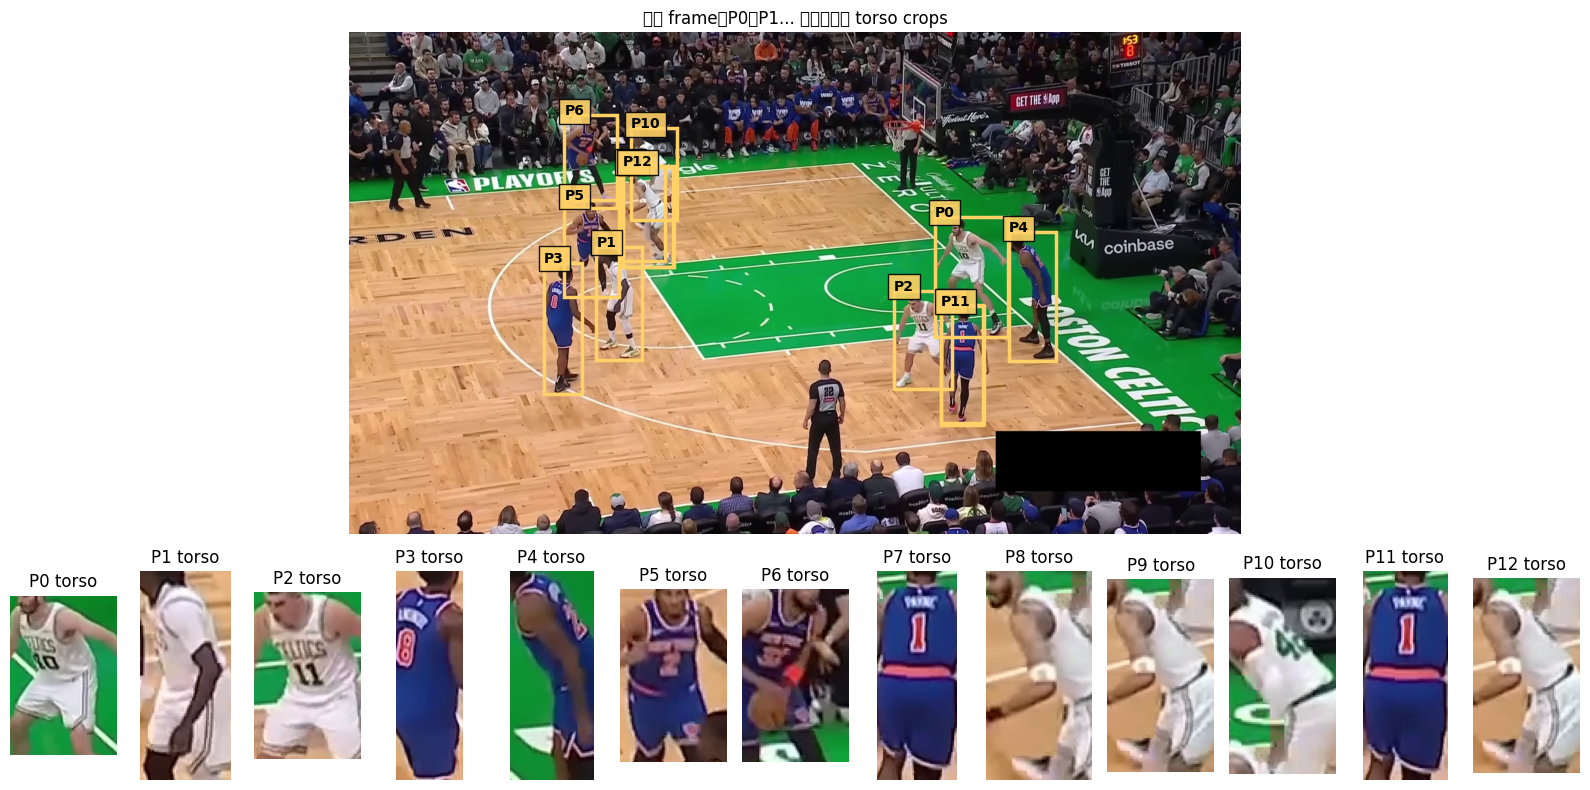

In [4]:
# 這一格要做什麼：把原圖 BBOX 編號與球衣 crop 編號並排檢查。
fig = plt.figure(figsize=(16, 8))
grid = fig.add_gridspec(2, max(3, len(crops)), height_ratios=[2.4, 1])
ax_main = fig.add_subplot(grid[0, :])
ax_main.imshow(frame)
ax_main.set_title("原始 frame：P0、P1... 對應下方的 torso crops")
ax_main.axis("off")
for local_index, player in enumerate(valid_players):
    x1, y1, x2, y2 = player.bbox_xyxy
    ax_main.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                fill=False, edgecolor="#FFD166", linewidth=2.5))
    ax_main.text(x1, y1, f"P{local_index}", color="black", weight="bold",
                 bbox={"facecolor": "#FFD166", "alpha": 0.9})

for index, crop in enumerate(crops):
    ax = fig.add_subplot(grid[1, index])
    ax.imshow(crop)
    ax.set_title(f"P{index} torso")
    ax.axis("off")
plt.tight_layout()
plt.show()


## Step 3｜把不同大小的 crop 轉成固定長度色彩特徵

我們在 HSV 空間統計「色相 H 與飽和度 S 的組合出現幾次」，得到二維直方圖，再攤平成向量並做 $L_2$ 正規化：

$$
\hat{\mathbf{h}}=\frac{\mathbf{h}}{\lVert\mathbf{h}\rVert_2+\epsilon}.
$$

這樣每張 crop 不論原始寬高，都會變成相同長度的數字；正規化則降低 crop 大小對總計數的影響。


In [5]:
# 這一格要做什麼：將每張 RGB crop 編碼成 HSV(H,S) 正規化直方圖。
def color_hist_embedding(crop_rgb, hue_bins=12, saturation_bins=8):
    '''Return a normalized 2D H/S histogram as one flat feature vector.'''
    hsv = cv2.cvtColor(np.ascontiguousarray(crop_rgb), cv2.COLOR_RGB2HSV)
    histogram = cv2.calcHist(
        [hsv], [0, 1], None,
        [hue_bins, saturation_bins],
        [0, 180, 0, 256],
    ).flatten().astype(np.float32)
    norm = float(np.linalg.norm(histogram))
    return histogram / max(norm, 1e-12)

features = np.vstack([color_hist_embedding(crop) for crop in crops])
print("number of crops:", len(crops))
print("feature matrix shape:", features.shape)
print("每一列是一位球員的 crop；每一欄是一個 H/S 顏色區間。")


number of crops: 13
feature matrix shape: (13, 96)
每一列是一位球員的 crop；每一欄是一個 H/S 顏色區間。


## Step 4｜用兩群 K-means 反覆做「分配」與「更新」

對第 $i$ 張 crop 的特徵 $\mathbf{x}_i$，分配到最近中心：

$$
c_i=\arg\min_{k\in\{0,1\}}\lVert\mathbf{x}_i-\boldsymbol{\mu}_k\rVert_2^2.
$$

再把同群特徵平均，更新中心 $\boldsymbol{\mu}_k$。重複直到分群不再改變或達到迭代上限。群編號 `0/1` 本身沒有隊名意義，所以後面只稱 Team A / Team B。


In [6]:
# 這一格要做什麼：用 NumPy 實作固定兩群的 K-means，讓每一步都可閱讀。
def kmeans_two_clusters(feature_matrix, max_iterations=50):
    if len(feature_matrix) < 2:
        raise ValueError("K-means 至少需要兩筆資料。")

    # 第一個中心取 P0；第二個中心取離 P0 最遠者，避免一開始太接近。
    first_center_index = 0
    distances_from_first = np.linalg.norm(
        feature_matrix - feature_matrix[first_center_index], axis=1
    )
    second_center_index = int(np.argmax(distances_from_first))
    centers = feature_matrix[[first_center_index, second_center_index]].copy()
    labels = np.full(len(feature_matrix), -1, dtype=int)

    iterations_run = 0
    for iteration in range(max_iterations):
        iterations_run = iteration + 1
        # distances[i, k]：第 i 位球員到第 k 個群中心的距離。
        distances = np.linalg.norm(
            feature_matrix[:, None, :] - centers[None, :, :], axis=2
        )
        new_labels = distances.argmin(axis=1)
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels

        # 每個中心改成該群所有特徵的平均；空群則保留原中心。
        for cluster_id in (0, 1):
            members = feature_matrix[labels == cluster_id]
            if len(members) > 0:
                centers[cluster_id] = members.mean(axis=0)
    return labels, centers, iterations_run

team_labels, cluster_centers, iterations = kmeans_two_clusters(features)
print("iterations:", iterations)
print("Team A members:", np.where(team_labels == 0)[0].tolist())
print("Team B members:", np.where(team_labels == 1)[0].tolist())


iterations: 3
Team A members: [0, 1, 2, 4, 6, 8, 9, 10, 12]
Team B members: [3, 5, 7, 11]


## Step 5｜把高維特徵壓成 2D，只為了看見群與群的距離

HSV histogram 有很多維，無法直接畫在平面上。我們用 PCA 的核心作法（中心化後做 SVD）投影到兩個方向。**K-means 使用的是原始完整特徵；2D 座標只用於視覺化，不是分群輸入。**


C:\Users\henry\AppData\Local\Temp\ipykernel_90316\1549250333.py:51: UserWarning: Glyph 30059 (\N{CJK UNIFIED IDEOGRAPH-756B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\henry\AppData\Local\Temp\ipykernel_90316\1549250333.py:51: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\henry\AppData\Local\Temp\ipykernel_90316\1549250333.py:51: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\henry\AppData\Local\Temp\ipykernel_90316\1549250333.py:51: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\henry\AppData\Local\Temp\ipykernel_90316\1549250333.py:51: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\henry\AppData\Local\Temp\ipykernel_90316\1549250333.py:51: UserWarning: Glyph 35222 (\

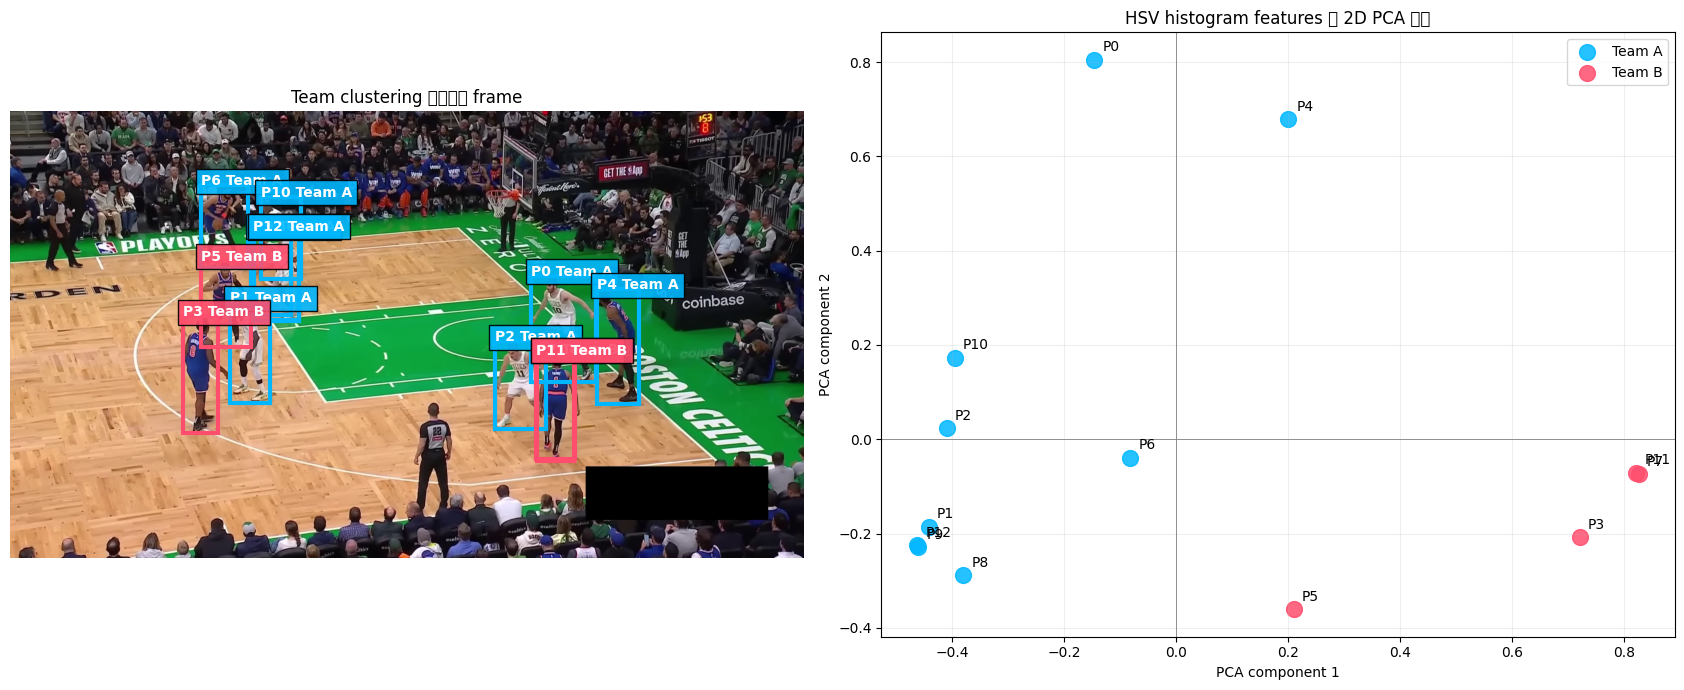

saved image: H:\Repos\basketball-hackathon-course\assets\results\d3_03_team_clustering.png
saved data: H:\Repos\basketball-hackathon-course\assets\results\d3_03_team_clustering.json


In [7]:
# 這一格要做什麼：同時呈現 crop、2D 特徵位置與畫回原圖的隊伍結果。
centered_features = features - features.mean(axis=0, keepdims=True)
_, _, vh = np.linalg.svd(centered_features, full_matrices=False)
component_count = min(2, vh.shape[0])
feature_2d = centered_features @ vh[:component_count].T
if component_count == 1:
    feature_2d = np.column_stack([feature_2d[:, 0], np.zeros(len(feature_2d))])

team_colors = {0: "#00B7FF", 1: "#FF4D6D"}
team_names = {0: "Team A", 1: "Team B"}
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# 左圖：將分群結果畫回真正的 BBOX，確認每個框與 team label 的關係。
axes[0].imshow(frame)
axes[0].set_title("Team clustering 畫回原始 frame")
axes[0].axis("off")
result_rows = []
for index, (player, cluster_id) in enumerate(zip(valid_players, team_labels)):
    x1, y1, x2, y2 = player.bbox_xyxy
    color = team_colors[int(cluster_id)]
    axes[0].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                fill=False, edgecolor=color, linewidth=3))
    axes[0].text(x1, y1, f"P{index} {team_names[int(cluster_id)]}",
                 color="white", weight="bold",
                 bbox={"facecolor": color, "alpha": 0.9})
    result_rows.append({
        "frame": FRAME_INDEX,
        "player_index": index,
        "source_detection_index": source_indices[index],
        "team_cluster": int(cluster_id),
        "team_name": team_names[int(cluster_id)],
        "bbox_xyxy": [float(value) for value in player.bbox_xyxy],
    })

# 右圖：每個點是一張 torso crop；距離近表示 HSV 色彩分布較相似。
for cluster_id in (0, 1):
    mask = team_labels == cluster_id
    axes[1].scatter(feature_2d[mask, 0], feature_2d[mask, 1], s=130,
                    color=team_colors[cluster_id], label=team_names[cluster_id], alpha=0.85)
for index, (x, y) in enumerate(feature_2d):
    axes[1].annotate(f"P{index}", (x, y), xytext=(6, 6), textcoords="offset points")
axes[1].axhline(0, color="gray", linewidth=0.6)
axes[1].axvline(0, color="gray", linewidth=0.6)
axes[1].set_title("HSV histogram features 的 2D PCA 視圖")
axes[1].set_xlabel("PCA component 1")
axes[1].set_ylabel("PCA component 2")
axes[1].legend()
axes[1].grid(alpha=0.2)

OUTPUT_IMAGE.parent.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
fig.savefig(OUTPUT_IMAGE, dpi=160, bbox_inches="tight")
plt.show()
save_json(result_rows, OUTPUT_JSON)
print("saved image:", OUTPUT_IMAGE)
print("saved data:", OUTPUT_JSON)


## 如何判讀結果與限制

請不要只問「有沒有分成兩色」，而要依序檢查：

1. **框是否正確？** 若 BBOX 包到裁判或觀眾，後面再好的分群也無法補救。
2. **crop 是否真的包含球衣？** 太多地板、皮膚或陰影會污染顏色特徵。
3. **同隊點是否在 2D 視圖靠近？** 若交錯，可能是光線、主客場球衣相似或 PCA 壓縮造成。
4. **Team A/B 是否在原圖合理？** 群編號不代表真實隊名，也不會辨認背號。

### 正式專案的延伸

- 從多個 frames 收集 crops，再以同一 `track_id` 多數決決定隊伍。
- 排除裁判，或加入「裁判」第三群。
- 使用預訓練影像 embedding 取代單純色彩直方圖。
- 結合 OCR / jersey-number model，從 team + number 進一步辨認球員。

## 本單元產出

- `assets/results/d3_03_team_clustering.png`：原圖分群與特徵散點對照。
- `assets/results/d3_03_team_clustering.json`：每個 player BBOX 的 Team A/B 結果。
